In [1]:
import pyarrow.parquet as pq
import polars as pl
pl.Config.set_tbl_cols(20)          # Show up to 20 columns
pl.Config.set_tbl_width_chars(200)  # Make the table wider in the console
pl.Config.set_fmt_str_lengths(50)   # Don't cut off long strings like stoch_key

results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260324_114114_01\master_metrics.parquet'

# Open the file metadata
parquet_file = pq.ParquetFile(results_path)

needed_cols = ["stoch_key", "ma_int", "era_int", "entry_lookback_units", "max_drawdown", "balance", "total_pos", "SL", "TP", "win_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

# 1. Get Row Count
print(f"Total Rows: {parquet_file.metadata.num_rows}")

# 2. Get Schema
print("Schema:")
print(parquet_file.schema)

Total Rows: 1276620
Schema:
required group field_id=-1 root {
  optional int32 field_id=-1 regime_id;
  optional int64 field_id=-1 era_int;
  optional int32 field_id=-1 side (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 ma_int;
  optional boolean field_id=-1 ma_reversion;
  optional int32 field_id=-1 entry_lookback_units;
  optional int32 field_id=-1 exit_window_h;
  optional boolean field_id=-1 use_stochastic;
  optional binary field_id=-1 stoch_key (String);
  optional boolean field_id=-1 use_bbw;
  optional int32 field_id=-1 bbw_periods;
  optional float field_id=-1 bbw_std;
  optional int32 field_id=-1 bbw_thresholds;
  optional float field_id=-1 SL;
  optional float field_id=-1 TP;
  optional int32 field_id=-1 total_pos;
  optional int32 field_id=-1 win_pos;
  optional float field_id=-1 balance;
  optional float field_id=-1 max_drawdown;
}



In [35]:
import polars as pl

def print_era_safety_tables_final(parquet_path: str, top_n: int = 10):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20230901, 20240301, 20240901, 20250301]
    
    display_cols = [
        "side", "ma_int", "entry_lookback_units", "exit_window_h", 
        "SL", "TP", "total_pos", "balance", "max_drawdown"
    ]

    for era in target_eras:
        print(f"\n" + "="*80)
        print(f"  ERA: {era} | RANKED BY LOWEST DRAWDOWN")
        print("="*80)

        # Filtering for statistically significant samples
        era_table = (
            lf.filter(
                (pl.col("era_int") == era) & 
                (pl.col("total_pos") > 50) &
                (pl.col("total_pos") < 1000)
            )
            .sort("max_drawdown", descending=False)
            .head(top_n)
            .collect()
        )

        if era_table.is_empty():
            print(f"No valid configurations found for Era {era}.")
        else:
            # Display the table
            print(era_table.select(display_cols))
            
            # THE FIX: Access the first element to get the raw float value
            best_dd_series = era_table["max_drawdown"]
            if best_dd_series.is_empty():
                print(f"\n>>> Era {era} Alpha: No drawdown data available")
            else:
                best_dd_value = best_dd_series[0]
                print(f"\n>>> Era {era} Alpha: Best DD achieved was {best_dd_value:.2%}")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260324_114114_01\master_metrics.parquet'
print_era_safety_tables_final(results_path)


  ERA: 20230901 | RANKED BY LOWEST DRAWDOWN
shape: (10, 9)
┌──────┬────────┬──────────────────────┬───────────────┬─────┬─────┬───────────┬────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookback_units ┆ exit_window_h ┆ SL  ┆ TP  ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---  ┆ ---    ┆ ---                  ┆ ---           ┆ --- ┆ --- ┆ ---       ┆ ---        ┆ ---          │
│ i8   ┆ i32    ┆ i32                  ┆ i32           ┆ f32 ┆ f32 ┆ i32       ┆ f32        ┆ f32          │
╞══════╪════════╪══════════════════════╪═══════════════╪═════╪═════╪═══════════╪════════════╪══════════════╡
│ -1   ┆ 0      ┆ 12                   ┆ 72            ┆ 0.1 ┆ 0.6 ┆ 53        ┆ 121.545235 ┆ 0.020812     │
│ -1   ┆ 0      ┆ 12                   ┆ 24            ┆ 0.1 ┆ 0.6 ┆ 53        ┆ 121.545235 ┆ 0.020812     │
│ -1   ┆ 0      ┆ 12                   ┆ 48            ┆ 0.1 ┆ 0.6 ┆ 53        ┆ 121.545235 ┆ 0.020812     │
│ -1   ┆ 0      ┆ 12                   ┆ 12            ┆ 0.1 ┆ 0.6 ┆

SL
0.2    0.029571
0.3    0.029676
0.4    0.030196
0.5    0.031302
0.1    0.032932
Name: max_drawdown, dtype: float32


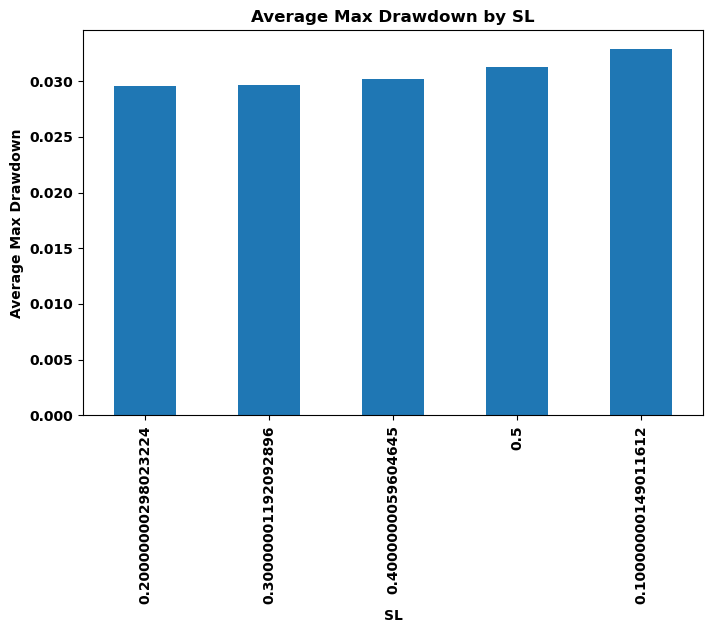

shape: (5, 2)
┌─────┬────────┐
│ SL  ┆ count  │
│ --- ┆ ---    │
│ f32 ┆ u32    │
╞═════╪════════╡
│ 0.4 ┆ 58929  │
│ 0.1 ┆ 128060 │
│ 0.3 ┆ 82632  │
│ 0.2 ┆ 104903 │
│ 0.5 ┆ 35560  │
└─────┴────────┘


In [42]:
import pandas as pd

df = df_master.select(["era_int", "SL", "max_drawdown"]).to_pandas()

# Average max_drawdown per SL
avg_dd_per_sl = df.groupby("SL")["max_drawdown"].mean().sort_values()
print(avg_dd_per_sl)

# Optional: visualize
import matplotlib.pyplot as plt
avg_dd_per_sl.plot(kind="bar", figsize=(8,5), title="Average Max Drawdown by SL")
plt.ylabel("Average Max Drawdown")
plt.show()

top_n = 10
top_dd = (
    df_master.filter(pl.col("max_drawdown") <= df_master["max_drawdown"].quantile(0.1))
    .groupby("SL")
    .count()
)
print(top_dd)

In [44]:
import polars as pl
import matplotlib.pyplot as plt

# Aggregate by TP
df_tp = df_master.select(["era_int", "TP", "max_drawdown"]).to_pandas()

avg_dd_per_tp = df_tp.groupby("TP")["max_drawdown"].mean().sort_values()
print("Average max drawdown per TP:")
print(avg_dd_per_tp)

# Optional visualization
avg_dd_per_tp.plot(kind="bar", figsize=(8,5), title="Average Max Drawdown by TP")
plt.ylabel("Average Max Drawdown")
plt.show()

# Top-performing DD trades per TP
top_n = 10
top_dd_tp = (
    df_master.filter(pl.col("max_drawdown") <= df_master["max_drawdown"].quantile(0.1))
    .groupby("TP")
    .count()
)
print(top_dd_tp)

AttributeError: 'DataFrame' object has no attribute 'select'

In [43]:
# Map era -> volatility
era_vol_map = {20230901: 61.7, 20240301: 154.7, 20240901: 49.2, 20250301: 106.6}

df_master = df_master.to_pandas()
df_master['volatility_pct'] = df_master['era_int'].map(era_vol_map)

# Check correlation: max_drawdown vs volatility per SL
for sl in sorted(df_master['SL'].unique()):
    sub = df_master[df_master['SL'] == sl]
    rho = sub['max_drawdown'].corr(sub['volatility_pct'], method='spearman')
    print(f"SL={sl}: spearman rho (DD vs Volatility) = {rho:.3f}")

SL=0.10000000149011612: spearman rho (DD vs Volatility) = 0.059
SL=0.20000000298023224: spearman rho (DD vs Volatility) = 0.060
SL=0.30000001192092896: spearman rho (DD vs Volatility) = 0.075
SL=0.4000000059604645: spearman rho (DD vs Volatility) = 0.072
SL=0.5: spearman rho (DD vs Volatility) = 0.089


In [11]:
import polars as pl

def print_era_safety_tables_stoch(parquet_path: str, top_n: int = 15):
    lf = pl.scan_parquet(parquet_path)
    target_eras = [20240301, 20240901, 20250301]
    
    display_cols = [
        "side", "ma_int", "entry_lookback_units", "exit_window_h", 
        "SL", "TP", "total_pos", "balance", "max_drawdown"
    ]

    for era in target_eras:
        print(f"\n" + "="*80)
        print(f"  ERA: {era} | STOCHASTIC K6 ONLY | RANKED BY LOWEST DD")
        print("="*80)

        era_table = (
            lf.filter(
                (pl.col("era_int") == era) & 
                (pl.col("stoch_key").str.contains("k6_d12_s12_l30_u70")) &           # Isolate K6 Logic
                (pl.col("total_pos") > 50) & 
                (pl.col("total_pos") < 1000)
            )
            .sort("max_drawdown", descending=False)
            .head(top_n)
            .collect()
        )

        if era_table.is_empty():
            print(f"No Stoch K6 configurations found for Era {era}.")
        else:
            print(era_table.select(display_cols))
            
            # THE DEFINITIVE FIX:
            # We index the Series with to get the float before formatting.
            best_dd_series = era_table["max_drawdown"]
            if best_dd_series.is_empty():
                print(f"\n>>> Era {era} Alpha: No drawdown data available")
            else:
                best_dd_value = best_dd_series[0]
                print(f"\n>>> Era {era} Alpha: Best DD achieved was {best_dd_value:.2%}")

# Usage
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260324_114114_01\master_metrics.parquet'
print_era_safety_tables_stoch(results_path)


  ERA: 20240301 | STOCHASTIC K6 ONLY | RANKED BY LOWEST DD
shape: (15, 9)
┌──────┬────────┬──────────────────────┬───────────────┬─────┬─────┬───────────┬────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookback_units ┆ exit_window_h ┆ SL  ┆ TP  ┆ total_pos ┆ balance    ┆ max_drawdown │
│ ---  ┆ ---    ┆ ---                  ┆ ---           ┆ --- ┆ --- ┆ ---       ┆ ---        ┆ ---          │
│ i8   ┆ i32    ┆ i32                  ┆ i32           ┆ f32 ┆ f32 ┆ i32       ┆ f32        ┆ f32          │
╞══════╪════════╪══════════════════════╪═══════════════╪═════╪═════╪═══════════╪════════════╪══════════════╡
│ 1    ┆ 8      ┆ 8                    ┆ 72            ┆ 0.3 ┆ 1.2 ┆ 51        ┆ 104.174797 ┆ 0.041277     │
│ 1    ┆ 8      ┆ 8                    ┆ 48            ┆ 0.3 ┆ 1.2 ┆ 51        ┆ 104.174797 ┆ 0.041277     │
│ 1    ┆ 8      ┆ 8                    ┆ 24            ┆ 0.3 ┆ 1.2 ┆ 51        ┆ 104.174797 ┆ 0.041277     │
│ 1    ┆ 8      ┆ 8                    ┆ 48          

In [ ]:
def find_robust_winners(parquet_path: str):
    lf = pl.scan_parquet(parquet_path)
    
    # 1. Broad filter for "survival"
    base_filter = (pl.col("total_pos") > 15) & (pl.col("max_drawdown") < 0.05)
    params = ["side", "ma_int", "entry_lookback_units", "exit_window_h", "SL", "TP", "stoch_key"]

    # 2. Get data for all eras at once, but only where they meet the criteria
    # We use a window function to count how many eras each strategy appears in
    winners = (
        lf.filter(base_filter)
        .groupby(params)
        .agg([
            pl.count("era_int").alias("era_count"),
            pl.mean("balance").alias("avg_balance"),
            pl.max("max_drawdown").alias("worst_drawdown"),
            pl.sum("total_pos").alias("total_trades")
        ])
        # ONLY keep strategies that appeared in all 3 eras
        .filter(pl.col("era_count") == 3)
        .sort("worst_drawdown")
    ).collect()

    print(f"Found {len(winners)} Unique Robust Configurations:")
    print(winners.head(20))

find_robust_winners(results_path)

Found 7193 Unique Robust Configurations:
shape: (20, 11)
┌──────┬────────┬──────────────────────┬───────────────┬─────┬─────┬────────────────────┬───────────┬─────────────┬────────────────┬──────────────┐
│ side ┆ ma_int ┆ entry_lookback_units ┆ exit_window_h ┆ SL  ┆ TP  ┆ stoch_key          ┆ era_count ┆ avg_balance ┆ worst_drawdown ┆ total_trades │
│ ---  ┆ ---    ┆ ---                  ┆ ---           ┆ --- ┆ --- ┆ ---                ┆ ---       ┆ ---         ┆ ---            ┆ ---          │
│ i8   ┆ i32    ┆ i32                  ┆ i32           ┆ f32 ┆ f32 ┆ str                ┆ u32       ┆ f32         ┆ f32            ┆ i32          │
╞══════╪════════╪══════════════════════╪═══════════════╪═════╪═════╪════════════════════╪═══════════╪═════════════╪════════════════╪══════════════╡
│ 1    ┆ 12     ┆ 12                   ┆ 48            ┆ 0.5 ┆ 2.2 ┆ k6_d12_s12_l30_u70 ┆ 3         ┆ 113.617332  ┆ 0.008973       ┆ 55           │
│ 1    ┆ 12     ┆ 12                   ┆ 72            

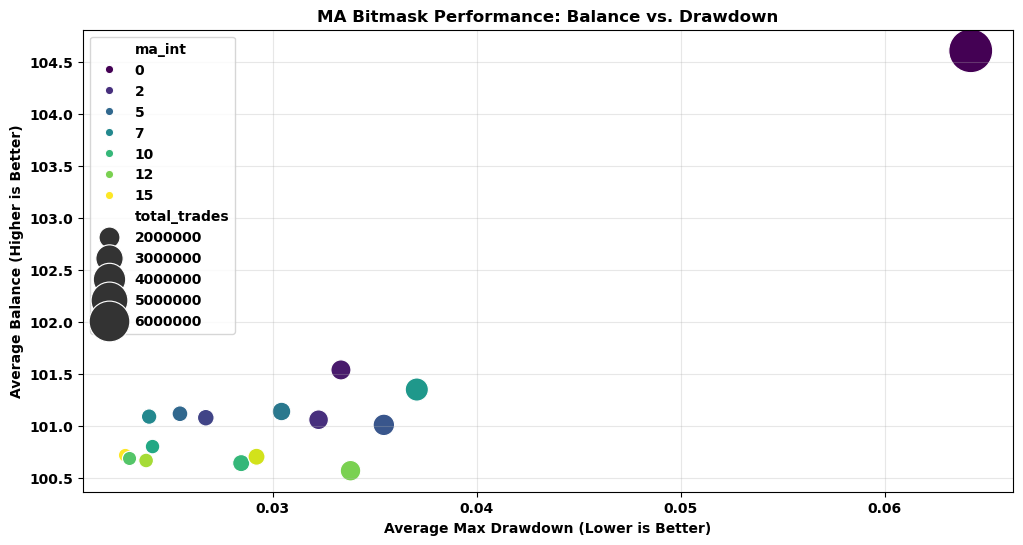


--- MA INT RANKING (Sorted by Safety) ---
 ma_int   avg_dd    avg_bal  total_trades  config_count  recovery_factor
     15 0.022773 100.718803       1191350         78800        31.563374
     11 0.022982 100.687851       1222200         80640        29.930424
     13 0.023794 100.668381       1266300         80640        28.090349
      7 0.023942 101.090324       1341760         84140        45.539617
      9 0.024109 100.802254       1256990         76720        33.276569
      5 0.025453 101.117889       1375780         80640        43.919044
      3 0.026720 101.079567       1463840         80640        40.403506
     10 0.028456 100.643013       1517440         79720        22.596467
     14 0.029207 100.704445       1508040         75840        24.118669
      6 0.030433 101.139511       1690920         80640        37.443395
      2 0.032250 101.060310       1826300         80640        32.878241
      1 0.033346 101.539124       1880470         75000        46.156155
     12 

In [12]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def rank_ma_performance(df: pl.DataFrame):
    """
    Ranks Moving Average Bitmask combinations by Risk and Profit.
    """
    # 1. Aggregate by ma_int
    ma_rankings = (
        df.groupby("ma_int")
          .agg([
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.col("balance").mean().alias("avg_bal"),
              pl.sum("total_pos").alias("total_trades"),
              pl.count().alias("config_count")
          ])
          .with_columns([
              # Recovery Factor: How many dollars of profit per dollar of risk
              ((pl.col("avg_bal") - 100) / pl.col("avg_dd")).alias("recovery_factor")
          ])
          .sort("avg_dd") # Rank by safest first
    )

    # 2. Visualization - Risk vs Reward per MA
    plt.figure(figsize=(12, 6))
    plot_df = ma_rankings.to_pandas()
    
    sns.scatterplot(
        data=plot_df, 
        x="avg_dd", 
        y="avg_bal", 
        size="total_trades", 
        hue="ma_int",
        palette="viridis",
        sizes=(100, 1000)
    )
    
    plt.title("MA Bitmask Performance: Balance vs. Drawdown")
    plt.xlabel("Average Max Drawdown (Lower is Better)")
    plt.ylabel("Average Balance (Higher is Better)")
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n--- MA INT RANKING (Sorted by Safety) ---")
    print(ma_rankings.to_pandas().to_string(index=False))

# --- EXECUTION ---
# Load only the essentials for 8GB RAM safety
needed_cols = ["ma_int", "max_drawdown", "balance", "total_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

rank_ma_performance(df_master)

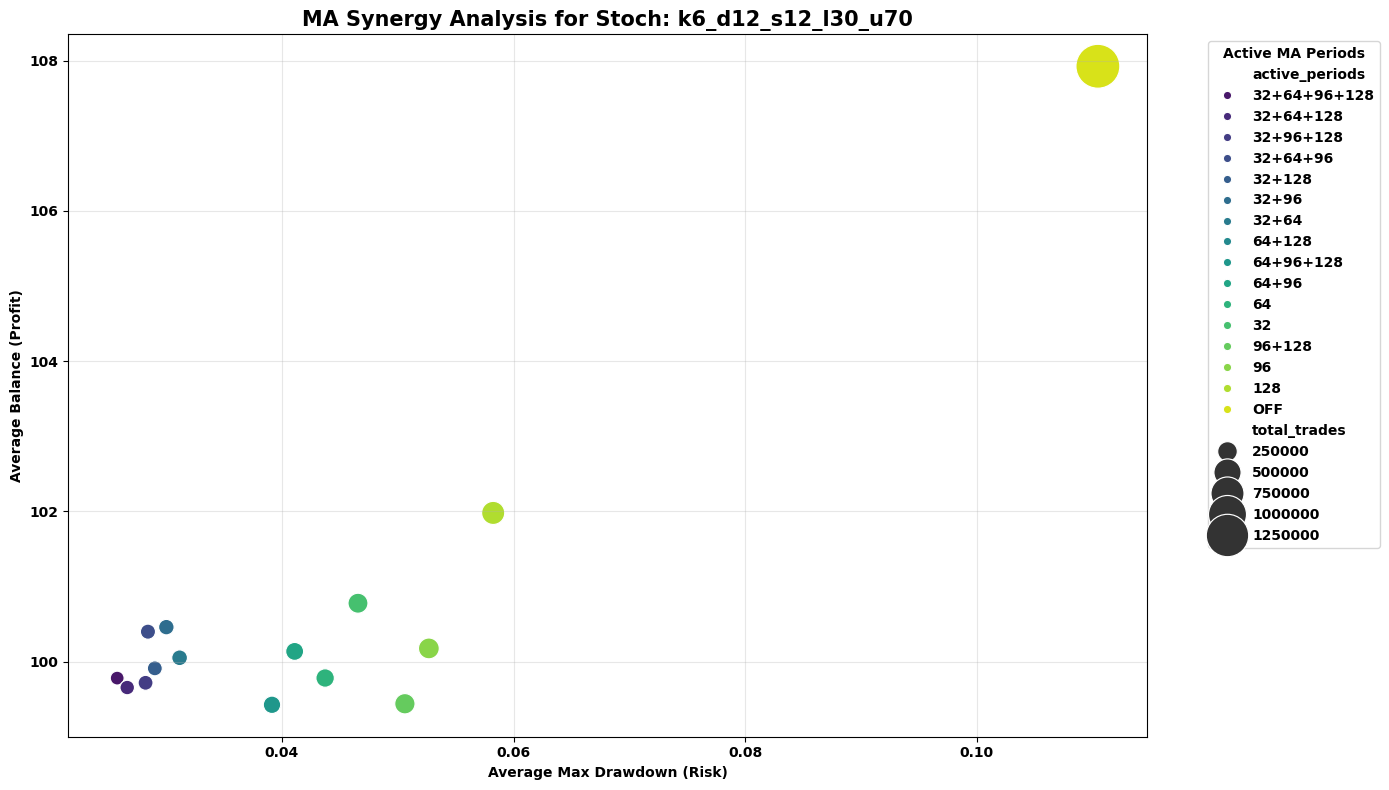


--- MA RANKING FOR k6_d12_s12_l30_u70 ---
 ma_int active_periods   avg_dd    avg_bal  recovery_factor  total_trades
     15   32+64+96+128 0.025779  99.779724        -8.544789        113675
     11      32+64+128 0.026645  99.654289       -12.974707        126980
     13      32+96+128 0.028228  99.717308       -10.014422        135380
      7       32+64+96 0.028435 100.397858        13.991882        139720
      9         32+128 0.029028  99.909622        -3.113483        135885
      5          32+96 0.030023 100.458260        15.263603        148120
      3          32+64 0.031167 100.050484         1.619761        152740
     10         64+128 0.039145  99.424400       -14.704405        191940
     14      64+96+128 0.039145  99.424400       -14.704405        191940
      6          64+96 0.041101 100.135246         3.290582        205520
      2             64 0.043733  99.780891        -5.010152        218820
      1             32 0.046569 100.776573        16.675580        26

In [14]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def rank_ma_for_specific_stoch(df: pl.DataFrame, target_stoch: str):
    """
    Ranks MA Bitmasks for a single, specific Stochastic configuration.
    """
    # Define bitwise mapping for the decoder
    ma_periods = [32, 64, 96, 128]

    def decode_ma_bits(val):
        if val == 0: return "OFF"
        active = [str(ma_periods[i]) for i in range(len(ma_periods)) if (val & (1 << i))]
        return "+".join(active)

    # 1. Filter for the Target Stoch and then Group by MA
    ma_rankings = (
        df.filter(pl.col("stoch_key") == target_stoch)
          .groupby("ma_int")
          .agg([
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.col("balance").mean().alias("avg_bal"),
              pl.sum("total_pos").alias("total_trades"),
              pl.count().alias("config_count")
          ])
          .with_columns([
              # Recovery Factor calculation
              ((pl.col("avg_bal") - 100) / pl.col("avg_dd")).alias("recovery_factor")
          ])
          .sort("avg_dd")
    )

    # 2. Prepare for plotting and decoding
    plot_df = ma_rankings.to_pandas()
    plot_df['active_periods'] = plot_df['ma_int'].apply(decode_ma_bits)
    
    # 3. Visualization
    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        data=plot_df, 
        x="avg_dd", 
        y="avg_bal", 
        size="total_trades", 
        hue="active_periods",
        palette="viridis",
        sizes=(100, 1000)
    )
    
    plt.title(f"MA Synergy Analysis for Stoch: {target_stoch}", fontsize=15)
    plt.xlabel("Average Max Drawdown (Risk)")
    plt.ylabel("Average Balance (Profit)")
    plt.legend(title="Active MA Periods", bbox_to_anchor=(1.05, 1), loc=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n--- MA RANKING FOR {target_stoch} ---")
    cols = ['ma_int', 'active_periods', 'avg_dd', 'avg_bal', 'recovery_factor', 'total_trades']
    print(plot_df[cols].to_string(index=False))

# --- EXECUTION ---
# Load columns including stoch_key for filtering
needed_cols = ["stoch_key", "ma_int", "max_drawdown", "balance", "total_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

rank_ma_for_specific_stoch(df_master, "k6_d12_s12_l30_u70")

In [3]:
import polars as pl
import pandas as pd

def print_component_breakdown(df: pl.DataFrame, min_trades=15, eps=1e-9):
    """
    Prints two separate tables: 
    1. MA Bitmask performance with trade-frequency buckets
    2. Stochastic key performance with trade-frequency buckets
    Includes efficiency per trade and decay between trade buckets.
    """

    # ================================
    # FUNCTION: ASSIGN TRADE BUCKETS
    # ================================
    def assign_bucket(col_name):
        return (
            pl.when(pl.col(col_name) < 80).then(pl.lit("low"))
            .when(pl.col(col_name) < 200).then(pl.lit("medium"))
            .when(pl.col(col_name) < 400).then(pl.lit("high"))
            .otherwise(pl.lit("very_high"))
        )

    # ================================
    # 1. MA_INT BREAKDOWN
    # ================================
    print("\n" + "="*40)
    print(" 1. MOVING AVERAGE (MA_INT) BREAKDOWN ")
    print("="*40)

    ma_stats = (
        df.groupby("ma_int")
          .agg([
              pl.col("balance").mean().alias("avg_bal"),
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.sum("total_pos").alias("total_trades"),
              pl.count().alias("config_count"),
          ])
          .with_columns([
              (pl.col("total_trades") / pl.col("config_count")).alias("avg_trades"),
              ((pl.col("avg_bal") - 100) / (pl.col("avg_dd") + eps)).alias("efficiency"),
          ])
          .with_columns([
              assign_bucket("avg_trades").alias("trade_bucket"),
              # Efficiency per trade
              (pl.col("efficiency") / (pl.col("avg_trades") + eps)).alias("efficiency_per_trade"),
          ])
          .filter(pl.col("avg_trades") >= min_trades)
    )

    # Pivot to measure decay
    ma_bucket = (
        ma_stats.groupby(["ma_int", "trade_bucket"])
                .agg(pl.col("efficiency").mean().alias("bucket_eff"))
                .pivot(values="bucket_eff", index="ma_int", columns="trade_bucket")
    )

    for col in ["low", "medium", "high", "very_high"]:
        if col not in ma_bucket.columns:
            ma_bucket = ma_bucket.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

    ma_bucket = ma_bucket.with_columns([
        (pl.col("high") - pl.col("medium")).alias("decay_med_to_high"),
        (pl.col("very_high") - pl.col("high")).alias("decay_high_to_vhigh"),
    ])

    ma_stats_final = (
        ma_stats.groupby("ma_int")
                .agg([
                    pl.col("efficiency").mean().alias("mean_efficiency"),
                    pl.col("efficiency_per_trade").mean().alias("mean_eff_per_trade"),
                    pl.col("avg_trades").mean().alias("mean_trades"),
                ])
                .join(ma_bucket.select(["ma_int", "decay_med_to_high", "decay_high_to_vhigh"]),
                      on="ma_int", how="left")
                .sort("mean_eff_per_trade", descending=True)
    )

    print(ma_stats_final.to_pandas().to_string(index=False))

    # ================================
    # 2. STOCHASTIC KEY BREAKDOWN
    # ================================
    print("\n" + "="*40)
    print(" 2. STOCHASTIC KEY BREAKDOWN ")
    print("="*40)

    stoch_df = df.filter(pl.col("stoch_key") != "OFF")

    stoch_stats = (
        stoch_df.groupby("stoch_key")
                 .agg([
                     pl.col("balance").mean().alias("avg_bal"),
                     pl.col("max_drawdown").mean().alias("avg_dd"),
                     pl.sum("total_pos").alias("total_trades"),
                     pl.count().alias("config_count"),
                 ])
                 .with_columns([
                     (pl.col("total_trades") / pl.col("config_count")).alias("avg_trades"),
                     ((pl.col("avg_bal") - 100) / (pl.col("avg_dd") + eps)).alias("efficiency"),
                 ])
                 .with_columns([
                     assign_bucket("avg_trades").alias("trade_bucket"),
                     (pl.col("efficiency") / (pl.col("avg_trades") + eps)).alias("efficiency_per_trade"),
                 ])
                 .filter(pl.col("avg_trades") >= min_trades)
    )

    # Pivot for decay
    stoch_bucket = (
        stoch_stats.groupby(["stoch_key", "trade_bucket"])
                   .agg(pl.col("efficiency").mean().alias("bucket_eff"))
                   .pivot(values="bucket_eff", index="stoch_key", columns="trade_bucket")
    )

    for col in ["low", "medium", "high", "very_high"]:
        if col not in stoch_bucket.columns:
            stoch_bucket = stoch_bucket.with_columns(pl.lit(None).cast(pl.Float64).alias(col))

    stoch_bucket = stoch_bucket.with_columns([
        (pl.col("high") - pl.col("medium")).alias("decay_med_to_high"),
        (pl.col("very_high") - pl.col("high")).alias("decay_high_to_vhigh"),
    ])

    stoch_stats_final = (
        stoch_stats.groupby("stoch_key")
                   .agg([
                       pl.col("efficiency").mean().alias("mean_efficiency"),
                       pl.col("efficiency_per_trade").mean().alias("mean_eff_per_trade"),
                       pl.col("avg_trades").mean().alias("mean_trades"),
                   ])
                   .join(stoch_bucket.select(["stoch_key", "decay_med_to_high", "decay_high_to_vhigh"]),
                         on="stoch_key", how="left")
                   .sort("mean_eff_per_trade", descending=True)
    )

    print(stoch_stats_final.head(20).to_pandas().to_string(index=False))

# --- EXECUTION ---
needed_cols = ["stoch_key", "ma_int", "max_drawdown", "balance", "total_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

print_component_breakdown(df_master)


 1. MOVING AVERAGE (MA_INT) BREAKDOWN 
 ma_int  mean_efficiency  mean_eff_per_trade  mean_trades  decay_med_to_high  decay_high_to_vhigh
      7        45.539613            2.855729    15.946755                NaN                  NaN
      5        43.919041            2.574272    17.060764                NaN                  NaN
      3        40.403503            2.225748    18.152778                NaN                  NaN
     15        31.563372            2.087710    15.118655                NaN                  NaN
      9        33.276567            2.031025    16.384124                NaN                  NaN
     11        29.930422            1.974791    15.156250                NaN                  NaN
      1        46.156155            1.840876    25.072933                NaN                  NaN
     13        28.090346            1.788838    15.703125                NaN                  NaN
      6        37.443393            1.785676    20.968750                NaN  

C:\Users\Owner\AppData\Local\Temp\ipykernel_15072\3654500637.py:54: DeprecationWarning: In a future version of polars, the default `aggregate_function` will change from `'first'` to `None`. Please pass `'first'` to keep the current behaviour, or `None` to accept the new one.
  .pivot(values="bucket_eff", index="ma_int", columns="trade_bucket")
C:\Users\Owner\AppData\Local\Temp\ipykernel_15072\3654500637.py:112: DeprecationWarning: In a future version of polars, the default `aggregate_function` will change from `'first'` to `None`. Please pass `'first'` to keep the current behaviour, or `None` to accept the new one.
  .pivot(values="bucket_eff", index="stoch_key", columns="trade_bucket")


In [10]:
# --- CELL: COMBINATION ROBUSTNESS ANALYSIS (with WIN RATE) ---
import itertools
import polars as pl

# --- CONFIG ---
TOP_N_MA = 5
TOP_N_STOCH = 5
MIN_TRADES_PER_CONFIG = 15
EPS = 1e-9

# --- SELECT TOP MA_INT AND STOCHASTIC KEYS ---
top_ma = (
    df_master.groupby("ma_int")
             .agg([
                 ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + EPS)).alias("recovery_factor")
             ])
             .sort("recovery_factor", descending=True)
             .head(TOP_N_MA)
             .select("ma_int")
             .to_series()
             .to_list()
)

top_stoch = (
    df_master.filter(pl.col("stoch_key") != "OFF")
             .groupby("stoch_key")
             .agg([
                 ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + EPS)).alias("recovery_factor")
             ])
             .sort("recovery_factor", descending=True)
             .head(TOP_N_STOCH)
             .select("stoch_key")
             .to_series()
             .to_list()
)

# --- CREATE ALL COMBINATIONS ---
combinations = list(itertools.product(top_ma, top_stoch))

# --- EVALUATE COMBINATIONS ---
comb_stats = []
for ma_int, stoch_key in combinations:
    df_sub = df_master.filter(
        (pl.col("ma_int") == ma_int) &
        (pl.col("stoch_key") == stoch_key)
    )
    if df_sub.height == 0:
        continue
    
    avg_bal = df_sub["balance"].mean()
    avg_dd = df_sub["max_drawdown"].mean()
    avg_trades = df_sub["total_pos"].sum() / df_sub.height
    eff = (avg_bal - 100) / (avg_dd + EPS)
    eff_per_trade = eff / (avg_trades + EPS)
    era_count = df_sub["era_int"].n_unique()
    win_rate = df_sub["win_pos"].sum() / (df_sub["total_pos"].sum() + EPS)
    
    comb_stats.append({
        "ma_int": ma_int,
        "stoch_key": stoch_key,
        "avg_bal": avg_bal,
        "avg_dd": avg_dd,
        "avg_trades": avg_trades,
        "efficiency": eff,
        "eff_per_trade": eff_per_trade,
        "win_rate": win_rate,
        "era_coverage": era_count
    })

# --- RESULTS TABLE ---
df_comb = pl.DataFrame(comb_stats).sort("eff_per_trade", descending=True)

print("\n--- MA x STOCHASTIC COMBINATION ROBUSTNESS ---")
print(
    df_comb.select([
        "ma_int",
        "stoch_key",
        "avg_bal",
        "avg_dd",
        "avg_trades",
        "efficiency",
        "eff_per_trade",
        "win_rate",
        "era_coverage"
    ]).to_pandas().to_string(index=False)
)


--- MA x STOCHASTIC COMBINATION ROBUSTNESS ---
 ma_int          stoch_key    avg_bal   avg_dd  avg_trades  efficiency  eff_per_trade  win_rate  era_coverage
      3   k6_d6_s6_l20_u80 100.557679 0.006373    2.958333   87.504222      29.578892  0.200369             4
      7   k6_d6_s6_l20_u80 100.467264 0.006217    2.833333   75.154276      26.525038  0.189041             4
      5   k6_d6_s6_l20_u80 100.442530 0.006463    2.916667   68.466470      23.474218  0.183639             4
      1   k6_d6_s6_l20_u80 100.498527 0.008053    3.698565   61.907612      16.738280  0.180272             4
      0   k6_d6_s6_l20_u80 100.807981 0.024202   14.083333   33.384860       2.370523  0.140666             4
      7   k6_d6_s6_l30_u70 105.629640 0.064613   55.444444   87.128755       1.571461  0.159839             4
      5   k6_d6_s6_l30_u70 105.569212 0.065702   56.402778   84.764980       1.502851  0.159540             4
      3   k6_d6_s6_l30_u70 105.815285 0.069352   60.625000   83.851180  

In [28]:
import polars as pl
import pandas as pd

def rank_stoch_under_ma7(df: pl.DataFrame):
    """
    Ranks unique Stochastic keys specifically when ma_int=7 is applied.
    """
    # 1. Filter for the 'Shield' (ma_int 7)
    ma7_results = (
        df.filter(pl.col("ma_int") == 7)
        .groupby("stoch_key")
        .agg([
            pl.col("balance").median().alias("median_bal"),
            pl.col("max_drawdown").median().alias("median_dd"),
            pl.col("total_pos").median().alias("median_trades"),
            pl.col("balance").mean().alias("avg_bal"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.count().alias("config_count")
        ])
        .with_columns([
            # Monthly activity (Assuming 24 months)
            (pl.col("median_trades") / 24).alias("trades_per_month"),
            # Recovery Factor based on Medians
            ((pl.col("median_bal") - 100) / pl.col("median_dd")).alias("median_recovery")
        ])
        .sort("median_recovery", descending=True)
    )

    print(f"\n" + "="*95)
    print(f" STOCHASTIC ENGINE RANKING (Fixed at ma_int 7) ")
    print("="*95)
    
    pd_results = ma7_results.to_pandas()
    # Display top 15 for a clear overview
    cols = ['stoch_key', 'median_bal', 'median_dd', 'median_recovery', 'trades_per_month']
    print(pd_results[cols].head(15).to_string(index=False))

# --- EXECUTION ---
needed_cols = ["stoch_key", "ma_int", "max_drawdown", "balance", "total_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

rank_stoch_under_ma7(df_master)


 STOCHASTIC ENGINE RANKING (Fixed at ma_int 7) 
         stoch_key  median_bal  median_dd  median_recovery  trades_per_month
k6_d12_s12_l20_u80  100.000000   0.000000              NaN          0.000000
 k6_d12_s6_l20_u80  100.000000   0.000000              NaN          0.000000
 k6_d6_s12_l20_u80  100.000000   0.000000              NaN          0.000000
  k6_d6_s6_l30_u70  102.807922   0.055487        50.605186          2.020833
  k6_d6_s6_l20_u80  100.000000   0.005991         0.000000          0.083333
 k6_d6_s12_l30_u70   99.962578   0.038306        -0.976936          1.125000
 k6_d12_s6_l30_u70   99.699997   0.032509        -9.228186          0.916667
k6_d12_s12_l30_u70   98.805389   0.023750       -50.300440          0.458333


In [30]:
import polars as pl
import pandas as pd

def analyze_performance_by_era(df: pl.DataFrame, engine_key: str):
    """
    Ranks performance for each unique Era for a specific engine.
    Compares the 'Shield' (ma_int 7) against the 'Baseline' (ma_int 0).
    """
    # 1. Filter for the target engine and the two key MA settings
    era_data = (
        df.filter(
            (pl.col("stoch_key") == engine_key) & 
            (pl.col("ma_int").is_in([0, 7]))
        )
        .groupby(["era_int", "ma_int"])
        .agg([
            pl.col("balance").median().alias("median_bal"),
            pl.col("max_drawdown").median().alias("median_dd"),
            pl.col("total_pos").median().alias("median_trades")
        ])
        .with_columns([
            # Recovery Factor per Era
            ((pl.col("median_bal") - 100) / pl.col("median_dd")).alias("era_recovery")
        ])
        .sort(["era_int", "ma_int"])
    )

    print(f"\n" + "="*95)
    print(f" ERA PERFORMANCE BREAKDOWN: {engine_key} ")
    print("="*95)
    
    pd_era = era_data.to_pandas()
    cols = ['era_int', 'ma_int', 'median_bal', 'median_dd', 'era_recovery', 'median_trades']
    print(pd_era[cols].to_string(index=False))

# --- EXECUTION ---
needed_cols = ["stoch_key", "ma_int", "era_int", "max_drawdown", "balance", "total_pos"]
# Update results_path to your local path
df_master = pl.read_parquet(results_path, columns=needed_cols)

analyze_performance_by_era(df_master, "k6_d6_s6_l30_u70")


 ERA PERFORMANCE BREAKDOWN: k6_d6_s6_l30_u70 
 era_int  ma_int  median_bal  median_dd  era_recovery  median_trades
20230901       0   95.593285   0.133955    -32.897060          117.5
20230901       7   97.283707   0.055487    -48.953821           44.0
20240301       0  107.027359   0.086893     80.873783          120.0
20240301       7  102.930321   0.045241     64.771019           44.0
20240901       0  105.013420   0.091667     54.691623          127.0
20240901       7  106.418320   0.046935    136.749192           41.0
20250301       0  113.383537   0.147622     90.660820          190.0
20250301       7  105.993156   0.075247     79.646130           73.0


In [32]:
import polars as pl
import pandas as pd

def analyze_lookback_by_era(df: pl.DataFrame, engine_key: str):
    """
    Ranks entry_lookback_units for each Era.
    Filters specifically for your 'Shield' (ma_int 7) to see the production setup.
    """
    # 1. Filter for the Alpha King and the Shield
    lookback_data = (
        df.filter(
            (pl.col("stoch_key") == engine_key) & 
            (pl.col("ma_int") == 7)
        )
        .groupby(["era_int", "entry_lookback_units"])
        .agg([
            pl.col("balance").median().alias("median_bal"),
            pl.col("max_drawdown").median().alias("median_dd"),
            pl.col("total_pos").median().alias("median_trades")
        ])
        .with_columns([
            # Recovery Factor per Lookback/Era combo
            ((pl.col("median_bal") - 100) / pl.col("median_dd")).alias("era_recovery")
        ])
        .sort(["era_int", "era_recovery"], descending=[False, True])
    )

    print(f"\n" + "="*95)
    print(f" LOOKBACK ANALYSIS BY ERA (Fixed: {engine_key} @ ma_int 7) ")
    print("="*95)
    
    pd_lookback = lookback_data.to_pandas()
    cols = ['era_int', 'entry_lookback_units', 'median_bal', 'era_recovery', 'median_trades']
    print(pd_lookback[cols].to_string(index=False))

# --- EXECUTION ---
needed_cols = ["stoch_key", "ma_int", "era_int", "entry_lookback_units", "max_drawdown", "balance", "total_pos"]
df_master = pl.read_parquet(results_path, columns=needed_cols)

analyze_lookback_by_era(df_master, "k6_d6_s6_l30_u70")


 LOOKBACK ANALYSIS BY ERA (Fixed: k6_d6_s6_l30_u70 @ ma_int 7) 
 era_int  entry_lookback_units  median_bal  era_recovery  median_trades
20230901                    12  100.487732     16.478419           16.0
20230901                     6   92.942657    -65.409410           74.0
20230901                     8   96.208946    -68.323463           44.0
20240301                     6  111.233620    168.033155           78.0
20240301                     8  103.836166     77.040477           44.0
20240301                    12  100.419556     15.726501           21.0
20240901                     6  113.764587    196.544079           82.5
20240901                     8  107.480774    159.083688           41.0
20240901                    12  102.088890     64.254902           17.5
20250301                    12  104.949921     94.024899           32.0
20250301                     8  106.360901     78.836403           73.0
20250301                     6  107.594238     74.160375          107.5

In [5]:
# --- CELL: SL x TP ANALYSIS ---
import polars as pl
import numpy as np

# --- CONFIG ---
MIN_RR = 1.0  # minimum risk-reward ratio

# --- GET UNIQUE SL AND TP ---
unique_sl = df_master.select("SL").unique().to_series().to_list()
unique_tp = df_master.select("TP").unique().to_series().to_list()

# --- GENERATE VALID (SL, TP) COMBOS BASED ON MIN_RR ---
def prune_sl_tp(sl_vals, tp_vals, min_rr=1.0):
    """
    Returns list of (SL, TP) tuples where TP >= min_rr * SL
    """
    sl_arr = np.array(sl_vals, dtype=np.float32)
    tp_arr = np.array(tp_vals, dtype=np.float32)
    sl_arr = sl_arr[sl_arr > 0.0]
    tp_arr = tp_arr[tp_arr > 0.0]
    tp_sorted = np.sort(tp_arr)
    combos = []
    for s in sl_arr:
        threshold = s * min_rr
        pos = np.searchsorted(tp_sorted, threshold, side="left")
        combos.extend([(float(s), float(t)) for t in tp_sorted[pos:]])
    return combos

combos = prune_sl_tp(unique_sl, unique_tp, MIN_RR)

# --- AGGREGATE STATISTICS PER COMBO ---
combo_stats = []
for sl_val, tp_val in combos:
    df_sub = df_master.filter(
        (pl.col("SL") == sl_val) & (pl.col("TP") == tp_val)
    )
    if df_sub.height == 0:
        continue

    avg_bal = df_sub["balance"].mean()
    avg_dd = df_sub["max_drawdown"].mean()
    avg_trades = df_sub["total_pos"].sum() / df_sub.height
    rr_ratio = tp_val / (sl_val + 1e-9)

    combo_stats.append({
        "SL": sl_val,
        "TP": tp_val,
        "avg_balance": avg_bal,
        "avg_drawdown": avg_dd,
        "avg_trades": avg_trades,
        "rr_ratio": rr_ratio
    })

# --- CREATE RESULT TABLE ---
df_sl_tp = pl.DataFrame(combo_stats).sort("rr_ratio", descending=True)

# --- PRINT TOP RESULTS ---
print("\n--- SL x TP STATS ---")
print(df_sl_tp.head(20).to_pandas().to_string(index=False))

# --- CORRELATION CHECK ---
import pandas as pd
df_corr = df_sl_tp.to_pandas()
corr_matrix = df_corr[["rr_ratio", "avg_balance", "avg_trades", "avg_drawdown"]].corr()
print("\n--- CORRELATION MATRIX ---")
print(corr_matrix)


--- SL x TP STATS ---
 SL  TP  avg_balance  avg_drawdown  avg_trades  rr_ratio
0.1 2.4   100.791773      0.042296   24.084585 24.000000
0.1 2.2   101.031905      0.040596   24.082109 22.000000
0.1 2.0   101.190722      0.039489   24.082109 20.000000
0.1 1.8   101.857393      0.037122   24.082109 17.999999
0.1 1.6   102.633788      0.034432   24.082109 16.000000
0.1 1.4   102.297206      0.033410   24.082109 13.999999
0.2 2.4   101.425515      0.036342   24.083918 12.000000
0.1 1.2   102.070165      0.031927   24.080127 12.000000
0.2 2.2   101.281244      0.035538   24.083918 11.000000
0.2 2.0   101.536175      0.034281   24.083918 10.000000
0.1 1.0   102.080190      0.029002   24.080127 10.000000
0.2 1.8   101.702995      0.032255   24.083918  9.000000
0.3 2.4   100.565389      0.034660   24.086309  8.000000
0.2 1.6   102.014435      0.029689   24.083918  8.000000
0.1 0.8   102.460881      0.026298   24.080127  8.000000
0.3 2.2   100.522792      0.033624   24.086309  7.333333
0.2 1.4 


--- TOTAL_POS RANGE ---
Minimum total_pos: 0
Maximum total_pos: 667
Number of unique total_pos values: 246

Some example unique total_pos values:
shape: (20,)
Series: 'total_pos' [i32]
[
	0
	1
	2
	3
	4
	5
	6
	7
	8
	9
	10
	11
	12
	13
	14
	15
	16
	17
	18
	19
]


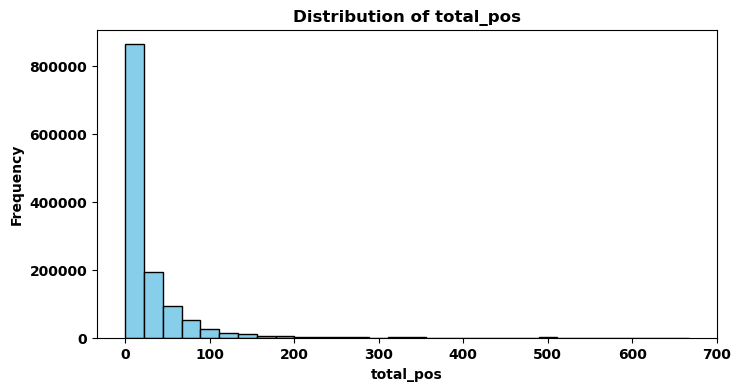

In [6]:
# --- CELL: TOTAL_POS RANGE CHECK ---
import polars as pl

# Check min and max total_pos in the dataset
min_trades = df_master["total_pos"].min()
max_trades = df_master["total_pos"].max()
unique_trades = df_master["total_pos"].unique().sort()

print("\n--- TOTAL_POS RANGE ---")
print(f"Minimum total_pos: {min_trades}")
print(f"Maximum total_pos: {max_trades}")
print(f"Number of unique total_pos values: {len(unique_trades)}")
print("\nSome example unique total_pos values:")
print(unique_trades[:20])  # show first 20 unique values for brevity

# Optional: histogram of trade counts
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    plt.hist(df_master["total_pos"].to_numpy(), bins=30, color='skyblue', edgecolor='black')
    plt.title("Distribution of total_pos")
    plt.xlabel("total_pos")
    plt.ylabel("Frequency")
    plt.show()
except ImportError:
    print("matplotlib not installed; skipping histogram.")

In [9]:
# --- CELL: BEST SL x TP FOR SELECTED CONFIG --- 
import polars as pl

# --- CONFIG ---
TARGET_STOCH = "k6_d6_s6_l30_u70"
TARGET_MA = [5, 7]          # ma_int values
MIN_TRADES_PER_CONFIG = 30   # ensure some statistical relevance
EPS = 1e-9

# --- FILTER DATA ---
df_sub = df_master.filter(
    (pl.col("stoch_key") == TARGET_STOCH) &
    (pl.col("ma_int").is_in(TARGET_MA))
)

# --- GROUP BY SL / TP ---
# assuming df_master has 'sl' and 'tp' columns
sl_tp_stats = (
    df_sub.groupby(["SL", "TP"])
          .agg([
              pl.mean("balance").alias("avg_balance"),
              pl.mean("max_drawdown").alias("avg_dd"),
              pl.sum("total_pos").alias("total_trades"),
              pl.sum("win_pos").alias("total_wins")
          ])
          .with_columns([
              ((pl.col("avg_balance") - 100) / (pl.col("avg_dd") + EPS)).alias("efficiency"),
              ((pl.col("avg_balance") - 100) / (pl.col("total_trades") + EPS)).alias("eff_per_trade"),
              (pl.col("total_wins") / (pl.col("total_trades") + EPS)).alias("win_rate")
          ])
          .filter(pl.col("total_trades") >= MIN_TRADES_PER_CONFIG)
          .sort("eff_per_trade", descending=True)
)

print("\n--- BEST SL x TP FOR STOCHASTIC k6_d6_s6_l30_u70 AND MA_INT 5+7 ---")
print(sl_tp_stats.to_pandas().to_string(index=False))


--- BEST SL x TP FOR STOCHASTIC k6_d6_s6_l30_u70 AND MA_INT 5+7 ---
 SL  TP  avg_balance   avg_dd  total_trades  total_wins  efficiency  eff_per_trade  win_rate
0.1 1.6   111.909233 0.073991         32212        3016  160.955740       0.000370  0.093630
0.1 1.4   110.498871 0.069610         32212        3316  150.824773       0.000326  0.102943
0.1 1.8   109.943359 0.079424         32212        2572  125.193747       0.000309  0.079846
0.1 2.2   109.357880 0.089012         32212        2044  105.130465       0.000291  0.063455
0.1 2.0   109.335602 0.085381         32212        2246  109.339904       0.000290  0.069726
0.2 1.4   108.454849 0.054094         32212        5900  156.298351       0.000262  0.183162
0.1 2.4   108.083496 0.094012         32212        1810   85.983922       0.000251  0.056190
0.1 1.2   108.068375 0.069490         32212        3528  116.108663       0.000250  0.109524
0.2 1.6   108.021797 0.059041         32212        5170  135.867765       0.000249  0.160499
0

In [13]:
# --- CELL: ERA-BY-ERA CHECK FOR SELECTED STRATEGY ---
import polars as pl

# --- FILTER DATA FOR THE STRATEGY ---
selected_ma_ints = [5, 7]
selected_stoch = "k6_d6_s6_l30_u70"
selected_SL = 0.1
selected_TP = 2.0

df_strategy = df_master.filter(
    (pl.col("stoch_key") == selected_stoch) &
    (pl.col("ma_int").is_in(selected_ma_ints)) &
    (pl.col("SL") == selected_SL) &
    (pl.col("TP") == selected_TP)
)

# --- GROUP BY ERA AND CALCULATE STATS ---
era_stats = (
    df_strategy.groupby("era_int")
               .agg([
                   pl.col("balance").mean().alias("avg_balance"),
                   pl.col("max_drawdown").mean().alias("avg_dd"),
                   pl.col("total_pos").sum().alias("total_trades"),
                   pl.col("win_pos").sum().alias("total_wins"),
                   ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 1e-9)).alias("efficiency"),
                   ((pl.col("balance").mean() - 100) / ((pl.col("total_pos").sum() / df_strategy["era_int"].n_unique()) + 1e-9) / (pl.col("max_drawdown").mean() + 1e-9)).alias("eff_per_trade"),
                   (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate")
               ])
               .sort("era_int")
)

print("\n--- ERA-BY-ERA PERFORMANCE ---")
print(era_stats.to_pandas())


--- ERA-BY-ERA PERFORMANCE ---
    era_int  avg_balance    avg_dd  total_trades  total_wins  efficiency  \
0  20230901    90.837646  0.097478          6736         100  -93.994358   
1  20240301   112.922768  0.058086          7408         632  222.477486   
2  20240901   121.227257  0.064302          7400         758  330.117123   
3  20250301   112.354874  0.121660         10668         756  101.552221   

   eff_per_trade  win_rate  
0      -0.055816  0.014846  
1       0.120128  0.085313  
2       0.178442  0.102432  
3       0.038077  0.070866  


In [14]:
# --- ERA-SPECIFIC OPTIMAL SL/TP ANALYSIS ---
import polars as pl

# Filter for the losing era
era_id = 20230901
df_era = df_master.filter(
    (pl.col("era_int") == era_id) &
    (pl.col("stoch_key") == "k6_d6_s6_l30_u70") &
    (pl.col("ma_int").is_in([5,7]))  # ma_int = 5+7 combo
)

# Group by SL, TP, and lookback unit to calculate performance metrics
era_stats = (
    df_era.groupby(["SL","TP","entry_lookback_units"])
          .agg([
              pl.col("balance").mean().alias("avg_balance"),
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.col("total_pos").sum().alias("total_trades"),
              pl.col("win_pos").sum().alias("total_wins")
          ])
          .with_columns([
              ((pl.col("avg_balance") - 100) / (pl.col("avg_dd")+1e-9)).alias("efficiency"),
              ((pl.col("avg_balance") - 100) / (pl.col("avg_dd")+1e-9) / (pl.col("total_trades")+1e-9)).alias("eff_per_trade"),
              (pl.col("total_wins") / (pl.col("total_trades")+1e-9)).alias("win_rate")
          ])
          .sort("efficiency", descending=True)
)

print("\n--- ERA 20230901: SL/TP by Lookback Units ---")
print(era_stats.head(20).to_pandas())


--- ERA 20230901: SL/TP by Lookback Units ---
     SL   TP  entry_lookback_units  avg_balance    avg_dd  total_trades  \
0   0.3  2.4                    12   107.807838  0.023079           768   
1   0.3  2.2                    12   106.815956  0.023079           768   
2   0.3  2.0                    12   105.835182  0.023079           768   
3   0.2  2.4                    12   105.975014  0.024993           768   
4   0.4  2.4                    12   105.128601  0.021490           768   
5   0.4  1.8                    12   103.763496  0.016837           768   
6   0.3  1.8                    12   105.154015  0.023079           768   
7   0.2  2.2                    12   105.124023  0.024993           768   
8   0.4  2.2                    12   104.388878  0.021490           768   
9   0.4  2.0                    12   103.879585  0.019901           768   
10  0.3  1.6                    12   104.164009  0.023079           768   
11  0.4  1.6                    12   102.962044  0.01

In [16]:
# --- CELL: LOOKBACK vs WIN RATE CORRELATION (FIXED) ---
import polars as pl

MIN_TRADES = 50

# --- AGGREGATE FIRST ---
df_lb = (
    df_master
    .filter(pl.col("total_pos") >= MIN_TRADES)
    .groupby(["era_int", "entry_lookback_units"])
    .agg([
        pl.col("total_pos").sum().alias("total_trades"),
        pl.col("win_pos").sum().alias("total_wins")
    ])
    .with_columns(
        (pl.col("total_wins") / pl.col("total_trades")).alias("win_rate"),
        pl.col("entry_lookback_units").cast(pl.Float64).alias("lookback_f")
    )
    .sort(["era_int", "entry_lookback_units"])
)

print("\n--- WIN RATE BY ERA & LOOKBACK UNIT ---")
print(df_lb.to_pandas().to_string(index=False))

# --- CORRELATION PER ERA (SAFE CAST) ---
corr_stats = (
    df_lb
    .groupby("era_int")
    .agg([
        pl.corr("lookback_f", "win_rate").alias("corr_lookback_winrate"),
        pl.count().alias("num_lookbacks")
    ])
    .sort("era_int")
)

print("\n--- CORRELATION: LOOKBACK UNIT vs WIN RATE (PER ERA) ---")
print(corr_stats.to_pandas().to_string(index=False))


--- WIN RATE BY ERA & LOOKBACK UNIT ---
 era_int  entry_lookback_units  total_trades  total_wins  win_rate  lookback_f
20230901                     6       2651800      338239  0.127551         6.0
20230901                     8        744975       97892  0.131403         8.0
20230901                    12         21700        4310  0.198618        12.0
20240301                     6       2797760      384387  0.137391         6.0
20240301                     8        956795      147136  0.153780         8.0
20240901                     6       3248830      485680  0.149494         6.0
20240901                     8        956635      142895  0.149373         8.0
20240901                    12         39900        3712  0.093033        12.0
20250301                     6       4900665      659912  0.134658         6.0
20250301                     8       2846790      418616  0.147048         8.0
20250301                    12        211185       33108  0.156772        12.0

--- CORREL

In [5]:
# --- CELL: BEST TP PER ERA (FIXED STOCH + MA_INT 5/7) ---
import polars as pl

EPS = 1e-9

# Filter once (important for correctness & speed)
df_base = df_master.filter(
    (pl.col("stoch_key") == "k6_d6_s6_l30_u70") &
    (pl.col("ma_int").is_in([5, 7])) &
    (pl.col("total_pos") > 0)
)

# Aggregate by era + TP
df_tp_era = (
    df_base
    .group_by(["era_int", "TP"])
    .agg([
        pl.col("balance").mean().alias("avg_balance"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        pl.col("total_pos").sum().alias("total_trades"),
        pl.col("win_pos").sum().alias("total_wins"),
    ])
    .with_columns([
        ((pl.col("avg_balance") - 100) / (pl.col("avg_dd") + EPS)).alias("efficiency"),
        (pl.col("total_wins") / pl.col("total_trades")).alias("win_rate"),
    ])
    .with_columns(
        (pl.col("efficiency") / (pl.col("total_trades") + EPS)).alias("eff_per_trade")
    )
)

# Select BEST TP per era by efficiency (primary) then eff_per_trade (tie-break)
df_best_tp_per_era = (
    df_tp_era
    .sort(
        ["era_int", "efficiency", "eff_per_trade"],
        descending=[False, True, True]
    )
    .group_by("era_int")
    .head(1)
    .sort("era_int")
)

print("\n--- BEST TP PER ERA (k6_d6_s6_l30_u70 | MA_INT 5+7) ---")
print(
    df_best_tp_per_era.select([
        "era_int",
        "TP",
        "avg_balance",
        "avg_dd",
        "total_trades",
        "total_wins",
        "win_rate",
        "efficiency",
        "eff_per_trade",
    ]).to_pandas().to_string(index=False)
)


--- BEST TP PER ERA (k6_d6_s6_l30_u70 | MA_INT 5+7) ---
 era_int  TP  avg_balance   avg_dd  total_trades  total_wins  win_rate  efficiency  eff_per_trade
20230901 2.4   100.219269 0.068361         33680        3902  0.115855    3.207492       0.000095
20240301 1.0   107.658363 0.036541         14816        2746  0.185340  209.584274       0.014146
20240901 2.0   111.140892 0.056755         37000        7140  0.192973  196.299469       0.005305
20250301 1.4   117.639267 0.064358         32004        6366  0.198913  274.079773       0.008564


In [ ]:
# --- CELL: TOP-N ELITE TP AVG PER ERA (FIXED FOR POLARS 1.39) ---

TOP_N = 5
MIN_TRADES = 20

df_elite_tp = (
    df_tp_era
    .filter(pl.col("total_trades") >= MIN_TRADES)
    .sort(
        ["era_int", "efficiency", "eff_per_trade"],
        descending=[False, True, True]
    )
    .with_columns(
        pl.col("TP").cum_count().over("era_int").alias("rank")
    )
    .filter(pl.col("rank") < TOP_N)
)

df_tp_centroid = (
    df_elite_tp
    .group_by("era_int")
    .agg([
        pl.col("TP").mean().alias("tp_mean"),
        pl.col("TP").std().alias("tp_std"),
        pl.col("TP").min().alias("tp_min"),
        pl.col("TP").max().alias("tp_max"),
        pl.len().alias("num_tp"),
        pl.col("efficiency").mean().alias("mean_efficiency"),
    ])
    .sort("era_int")
)

print(df_tp_centroid.to_pandas().to_string(index=False))

 era_int  tp_mean   tp_std  tp_min  tp_max  num_tp  mean_efficiency
20230901 1.555556 0.630696     0.4     2.4       9       -32.805725
20240301 1.400000 0.547723     0.6     2.2       9       155.936935
20240901 1.600000 0.547723     0.8     2.4       9       167.230331
20250301 1.244444 0.630696     0.4     2.4       9       190.250809


In [2]:
import pandas as pd
import numpy as np

vol_data = [
    {"era_int": 20230901, "volatility_pct": 61.697750, "volatility_index": 0.616978},
    {"era_int": 20240301, "volatility_pct": 154.724207, "volatility_index": 1.547242},
    {"era_int": 20240901, "volatility_pct": 49.231199, "volatility_index": 0.492312},
    {"era_int": 20250301, "volatility_pct": 106.653570, "volatility_index": 1.066536},
]

# Build dataframe
vol_df = pd.DataFrame(vol_data)
tp_sl_df = pd.DataFrame([
    {"era_int": 20230901, "tp_mean": 2.4, "sl_mean": 0.25},
    {"era_int": 20240301, "tp_mean": 1.4, "sl_mean": 0.10},
    {"era_int": 20240901, "tp_mean": 2.1, "sl_mean": 0.10},
    {"era_int": 20250301, "tp_mean": 1.5, "sl_mean": 0.10},
])

# Merge on era_int
df = pd.merge(vol_df, tp_sl_df, on="era_int")

# Compute correlations
corr_tp = df["volatility_index"].corr(df["tp_mean"])
corr_sl = df["volatility_index"].corr(df["sl_mean"])

df, corr_tp, corr_sl

(    era_int  volatility_pct  volatility_index  tp_mean  sl_mean
 0  20230901       61.697750          0.616978      2.4     0.25
 1  20240301      154.724207          1.547242      1.4     0.10
 2  20240901       49.231199          0.492312      2.1     0.10
 3  20250301      106.653570          1.066536      1.5     0.10,
 np.float64(-0.8804221056229604),
 np.float64(-0.4364559765188498))

In [3]:
baseline_vol = 0.418
k = 0.8
Base_TP = 2.0

df["TP_adjusted"] = Base_TP / (1 + k * (df["volatility_index"] - baseline_vol))
df[["era_int","volatility_index","tp_mean","TP_adjusted"]]

,era_int,volatility_index,tp_mean,TP_adjusted
0,20230901,0.616978,2.4,1.725354
1,20240301,1.547242,1.4,1.050755
2,20240901,0.492312,2.1,1.887773
3,20250301,1.066536,1.5,1.316804


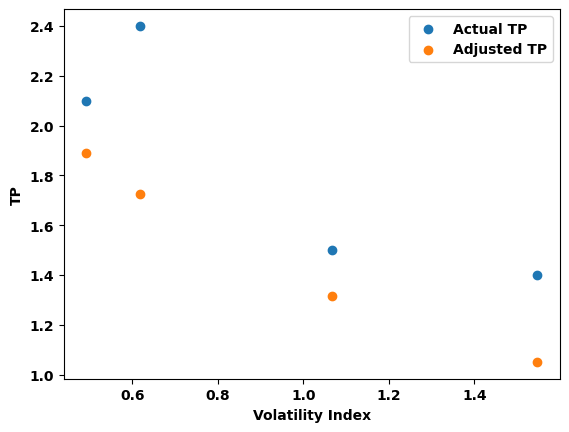

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["volatility_index"], df["tp_mean"], label="Actual TP")
plt.scatter(df["volatility_index"], df["TP_adjusted"], label="Adjusted TP")
plt.xlabel("Volatility Index")
plt.ylabel("TP")
plt.legend()
plt.show()